# RecruitAI — End-to-End Google Colab Implementation

**Goal:** Build a recruitment **decision-support** system that semantically matches job descriptions (JDs) with resumes, ranks candidates, identifies skill/experience gaps, and produces evidence-based explanations while keeping the final hiring decision with a human.

This notebook implements the project as a production-oriented prototype/reference implementation, not an autonomous hiring system.

## Architecture implemented

```text
Job Description
      |
      v
Requirement / text preparation
      |
      v
Sentence-Transformer Bi-Encoder
      |
      v
Top-K semantic retrieval
      |
      v
BERT / MiniLM Cross-Encoder
      |
      v
Re-ranking
      |
      +--> Skill-gap analysis
      +--> Experience-gap analysis
      +--> Evidence / explanation
      |
      v
Recruiter decision support
      |
      v
Human decision
```

## Models benchmarked

1. TF-IDF + cosine similarity
2. TF-IDF + Logistic Regression
3. MLP
4. Bi-LSTM
5. Sentence Transformer
6. BERT pair regressor
7. Cross-Encoder reranker
8. Final two-stage Bi-Encoder → Cross-Encoder pipeline

## Important dataset rule

The supplied CSV contains a leakage problem: `responsibilities` is identical to `responsibilities.1` for every row.  
Therefore, this notebook **does not use `responsibilities` as a resume-side feature**. It keeps `responsibilities.1` only on the JD side.

Protected/sensitive or strong proxy fields such as `address`, `age_requirement`, institution names, company names, and passing years are also excluded from ranking features.

## 0. Google Colab runtime setup

In Colab, use **Runtime → Change runtime type → GPU** before running the Transformer sections.

The classical baselines can run on CPU. The BERT and Cross-Encoder sections should use a GPU when available.

In [1]:
# Check runtime
import platform, sys, os

print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("PyTorch check:", e)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Install project dependencies

Run this once at the beginning of a fresh Colab runtime.

`sentence-transformers` provides the bi-encoder and Cross-Encoder APIs.  
`transformers` is used for the BERT regression experiment.  
`datasets` is used to prepare Transformer training datasets.

In [2]:
!pip -q install -U sentence-transformers transformers datasets accelerate faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.3 MB/s eta 0:00:00


In [3]:
# Record package versions for reproducibility
import importlib.metadata as md_pkg

for pkg in [
    "pandas", "numpy", "scikit-learn", "tensorflow",
    "torch", "transformers", "sentence-transformers",
    "datasets", "accelerate", "faiss-cpu"
]:
    try:
        print(f"{pkg}: {md_pkg.version(pkg)}")
    except Exception:
        pass

!pip freeze > requirements_snapshot.txt
print("Saved package snapshot: requirements_snapshot.txt")

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
tensorflow: 2.20.0
torch: 2.11.0+cu128
transformers: 5.15.0
sentence-transformers: 5.7.0
datasets: 5.0.1
accelerate: 1.14.0
faiss-cpu: 1.15.0
Saved package snapshot: requirements_snapshot.txt


## 2. Imports and reproducibility

In [4]:
import ast
import json
import math
import os
import random
import re
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    mean_absolute_error, mean_squared_error, ndcg_score
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

print("Seed:", SEED)

Seed: 42


## 3. Load the supplied CSV

### Option A — Upload directly to Colab
Run the next cell and select `resume_data_for_ranking(4).csv`.

### Option B — Google Drive
If you keep the dataset in Drive, set `USE_DRIVE = True` and update `DRIVE_CSV_PATH`.

In [5]:
USE_DRIVE = True
DRIVE_CSV_PATH = "/content/drive/MyDrive/RecruiterAI/resume_data_for_ranking.csv"

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CSV_PATH = DRIVE_CSV_PATH
else:
    from google.colab import files
    uploaded = files.upload()
    csv_candidates = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_candidates:
        raise ValueError("Please upload the RecruitAI CSV file.")
    CSV_PATH = csv_candidates[0]

print("Using:", CSV_PATH)

Mounted at /content/drive
Using: /content/drive/MyDrive/RecruiterAI/resume_data_for_ranking.csv


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df=pd.read_csv(CSV_PATH)
df.head(3)

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667


## 4. Data audit

We first inspect:

- row/column counts
- target quality
- missing values
- number of distinct JDs
- duplicate rows
- score distribution
- possible leakage

In [8]:
audit = {
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "unique_job_titles": int(df["job_position_name"].nunique(dropna=True)),
    "missing_matched_score": int(df["matched_score"].isna().sum()),
    "matched_score_min": float(df["matched_score"].min()),
    "matched_score_max": float(df["matched_score"].max()),
    "matched_score_mean": float(df["matched_score"].mean()),
    "matched_score_median": float(df["matched_score"].median()),
}

pd.Series(audit)

,0
rows,9544.000000
columns,35.000000
duplicate_rows,0.000000
unique_job_titles,28.000000
missing_matched_score,0.000000
matched_score_min,0.000000
matched_score_max,0.970000
matched_score_mean,0.660831
matched_score_median,0.683333


In [9]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_%").head(20))

,missing_%
languages,92.665549
proficiency_levels,92.665549
address,91.785415
issue_dates,78.960604
certification_skills,78.960604
certification_providers,78.960604
expiry_dates,78.960604
online_links,78.960604
extra_curricular_activity_types,64.103101
extra_curricular_organization_links,64.103101


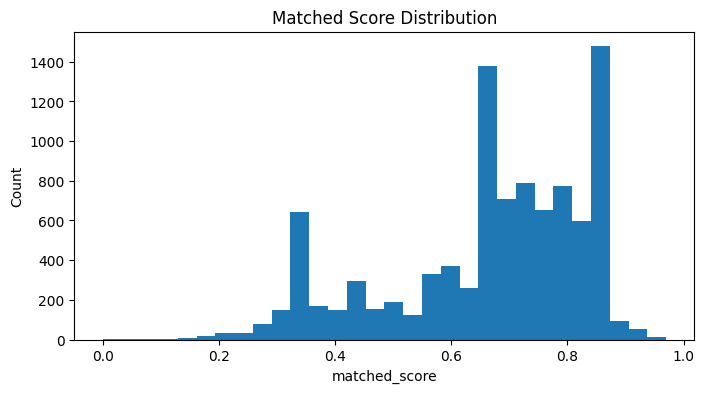

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(df["matched_score"], bins=30)
plt.title("Matched Score Distribution")
plt.xlabel("matched_score")
plt.ylabel("Count")
plt.show()

In [11]:
job_counts = df["job_position_name"].value_counts().sort_values(ascending=False)
display(job_counts.to_frame("candidate_rows"))

,candidate_rows
job_position_name,
Project Coordinator (Civil),342
Site Engineer,342
Civil Engineer,342
HR Officer,342
Database Administrator (DBA),341
AI Engineer,341
Mechanical Designer,341
Mechanical Engineer,341
"System Administrator (Operation & Maintenance of Server, Storage & Service Desk System)",341


## 5. Leakage audit — critical

If a resume feature directly contains the JD answer, the model may produce artificially high metrics.

The supplied data has a specific issue:

`responsibilities == responsibilities.1`

The following test verifies the equality rate.

In [12]:
resp_left = df["responsibilities"].fillna("").astype(str).str.strip()
resp_right = df["responsibilities.1"].fillna("").astype(str).str.strip()

leakage_rate = (resp_left == resp_right).mean()
print(f"Exact equality rate: {leakage_rate:.2%}")

if leakage_rate > 0.95:
    print("LEAKAGE FOUND: exclude resume-side 'responsibilities' from ranking features.")

Exact equality rate: 100.00%
LEAKAGE FOUND: exclude resume-side 'responsibilities' from ranking features.


## 6. Responsible-AI feature policy

### Used on the resume side

- career objective
- skills
- degree names
- major fields of study
- positions
- job-related skills
- certification skills

### Excluded from ranking

- `address` — location / PII proxy
- `age_requirement` — protected-age signal
- `passing_years` — can proxy age
- educational institution name — pedigree/proxy bias risk
- professional company names — employer-pedigree proxy
- languages/proficiency — no explicit JD language requirement in this dataset
- `responsibilities` — confirmed leakage
- target `matched_score`

These exclusions are deliberate. They can still be stored for display only if governance permits, but they should not influence the score in this prototype.

In [13]:
PROTECTED_OR_EXCLUDED = [
    "address",
    "age_requirement",
    "passing_years",
    "educational_institution_name",
    "professional_company_names",
    "company_urls",
    "locations",
    "languages",
    "proficiency_levels",
    "responsibilities",   # leakage
    "matched_score",      # target
]

print("Excluded from ranking:")
for col in PROTECTED_OR_EXCLUDED:
    print("-", col)

Excluded from ranking:
- address
- age_requirement
- passing_years
- educational_institution_name
- professional_company_names
- company_urls
- locations
- languages
- proficiency_levels
- responsibilities
- matched_score


## 7. Text cleaning and feature construction

The CSV stores many fields as Python-list-like strings, for example:

```text
"['Python', 'PyTorch', 'Azure']"
```

We convert these into clean text before vectorization/tokenization.

In [14]:
def flatten_nested(value):
    if isinstance(value, (list, tuple)):
        out = []
        for item in value:
            out.extend(flatten_nested(item))
        return out
    if value is None:
        return []
    return [str(value)]

def parse_list_like(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return flatten_nested(value)

    text = str(value).strip()
    if not text:
        return []

    if text.startswith("[") and text.endswith("]"):
        try:
            obj = ast.literal_eval(text)
            return [x.strip() for x in flatten_nested(obj) if str(x).strip() and str(x).lower() != "n/a"]
        except Exception:
            pass

    return [text]

def clean_value(value):
    if pd.isna(value):
        return ""

    text = str(value).strip()

    if text.startswith("[") and text.endswith("]"):
        values = parse_list_like(text)
        text = " ".join(values)

    text = re.sub(r"\s+", " ", text).strip()
    if text.lower() in {"nan", "none", "n/a"}:
        return ""
    return text

def build_labeled_text(row, fields):
    parts = []
    for col, label in fields:
        value = clean_value(row.get(col, ""))
        if value:
            parts.append(f"{label}: {value}")
    return " | ".join(parts)

In [15]:
RESUME_FIELDS = [
    ("career_objective", "Career Objective"),
    ("skills", "Skills"),
    ("degree_names", "Degrees"),
    ("major_field_of_studies", "Major"),
    ("positions", "Positions"),
    ("related_skils_in_job", "Job Skills"),
    ("certification_skills", "Certification Skills"),
]

JD_FIELDS = [
    ("job_position_name", "Role"),
    ("educationaL_requirements", "Education Requirements"),
    ("experiencere_requirement", "Experience Requirements"),
    ("responsibilities.1", "Responsibilities"),
    ("skills_required", "Required Skills"),
]

work = df.copy()

work["resume_text"] = work.apply(
    lambda row: build_labeled_text(row, RESUME_FIELDS), axis=1
)

work["job_text"] = work.apply(
    lambda row: build_labeled_text(row, JD_FIELDS), axis=1
)

work["pair_text"] = (
    "JOB DESCRIPTION: " + work["job_text"] +
    " [SEP] CANDIDATE RESUME: " + work["resume_text"]
)

work["candidate_id"] = np.arange(len(work))

display(work[[
    "candidate_id", "job_position_name",
    "resume_text", "job_text", "matched_score"
]].head(2))

,candidate_id,job_position_name,resume_text,job_text,matched_score
0,0,Senior Software Engineer,Career Objective: Big data analytics working a...,Role: Senior Software Engineer | Education Req...,0.85
1,1,Machine Learning (ML) Engineer,Career Objective: Fresher looking to join as a...,Role: Machine Learning (ML) Engineer | Educati...,0.75


## 8. Data-quality assertions

These fail early if a future version of the dataset changes unexpectedly.

In [16]:
assert work["matched_score"].notna().all(), "matched_score contains nulls"
assert work["matched_score"].between(0, 1).all(), "matched_score must be in [0, 1]"
assert work["resume_text"].str.len().gt(0).all(), "Some resume_text values are empty"
assert work["job_text"].str.len().gt(0).all(), "Some job_text values are empty"

# Make sure leakage field is not in the resume feature definition.
assert all(col != "responsibilities" for col, _ in RESUME_FIELDS)

print("All data-quality assertions passed.")

All data-quality assertions passed.


## 9. Train / validation / test split by job title

A random row split would expose the same JD text in both train and test.

Instead, `GroupShuffleSplit` holds out entire `job_position_name` groups.

With 28 job titles, the supplied dataset typically produces approximately:

- 18 training JDs
- 4 validation JDs
- 6 test JDs

Exact row counts are printed by the code.

In [17]:
outer = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

trainval_idx, test_idx = next(
    outer.split(work, groups=work["job_position_name"])
)

trainval_df = work.iloc[trainval_idx].reset_index(drop=True)
test_df = work.iloc[test_idx].reset_index(drop=True)

inner = GroupShuffleSplit(
    n_splits=1,
    test_size=0.14,
    random_state=SEED
)

train_idx, val_idx = next(
    inner.split(trainval_df, groups=trainval_df["job_position_name"])
)

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

def split_summary(name, frame):
    return {
        "split": name,
        "rows": len(frame),
        "job_titles": frame["job_position_name"].nunique()
    }

display(pd.DataFrame([
    split_summary("train", train_df),
    split_summary("validation", val_df),
    split_summary("test", test_df),
]))

assert set(train_df["job_position_name"]).isdisjoint(set(val_df["job_position_name"]))
assert set(train_df["job_position_name"]).isdisjoint(set(test_df["job_position_name"]))
assert set(val_df["job_position_name"]).isdisjoint(set(test_df["job_position_name"]))

print("No JD-title leakage across splits.")

,split,rows,job_titles
0,train,6133,18
1,validation,1363,4
2,test,2048,6


No JD-title leakage across splits.


In [18]:
print("TRAIN JOBS")
print(sorted(train_df["job_position_name"].unique()))
print("\nVALIDATION JOBS")
print(sorted(val_df["job_position_name"].unique()))
print("\nTEST JOBS")
print(sorted(test_df["job_position_name"].unique()))

TRAIN JOBS
['Civil Engineer', 'Data Engineer', 'Data Science Engineer', 'Database Administrator (DBA)', 'DevOps Engineer', 'Executive/ Sr. Executive -IT', 'Head of Internal Control & Compliance (ICC) - SEVP/DMD', 'Intern (Generative AI Engineering - 2D/3D Image Generation)', 'Machine Learning (ML) Engineer', 'Management Trainee - Mechanical', 'Marketing Officer', 'Mechanical Designer', 'Mechanical Engineer', 'Project Coordinator (Civil)', 'Senior Software Engineer', 'Senior iOS Engineer', 'Sr.Officer / Executive - Internal Audit', 'System Administrator (Operation & Maintenance of Server, Storage & Service Desk System)']

VALIDATION JOBS
['Asst. Manager/ Manger (Administrative)', 'Business Development Executive', 'Full Stack Developer (Python,React js)', 'Manager- Human Resource Management (HRM)\n']

TEST JOBS
['AI Engineer', 'Executive - VAT', 'Executive/ Senior Executive- Trade Marketing, Hygiene Products', 'HR Officer', 'Network Support Engineer', 'Site Engineer']


## 10. Evaluation design

### Ranking metrics

The primary task is ranking, so this notebook reports:

- **NDCG@10** — rewards putting candidates with higher ground-truth relevance near the top.
- **Recall@10** — overlap between predicted Top-10 and ground-truth Top-10.
- **MRR@10** — reciprocal rank of the first ground-truth Top-10 candidate found.
- **HitRate@10** — whether at least one ground-truth Top-10 candidate appears.

For Recall/MRR/HitRate, the **ground-truth relevant set is the ten highest `matched_score` candidates within each JD**.  
This avoids introducing an arbitrary global hiring threshold.

### Regression metrics

For models predicting the continuous score:

- MAE
- RMSE

### Classification baseline

The Logistic Regression experiment requires binary labels.  
For that baseline only, this notebook defines:

```text
relevant = matched_score >= 0.70
```

This is an experimental threshold, **not a hiring cutoff**.

In [19]:
def ranking_metrics(frame, pred_col, k=10, truth_k=10):
    ndcgs, recalls, mrrs, hits = [], [], [], []

    for _, group in frame.groupby("job_position_name"):
        g = group.copy()

        true_scores = g["matched_score"].to_numpy(dtype=float)
        pred_scores = g[pred_col].to_numpy(dtype=float)

        effective_k = min(k, len(g))
        effective_truth_k = min(truth_k, len(g))

        ndcgs.append(
            ndcg_score([true_scores], [pred_scores], k=effective_k)
        )

        true_top = set(
            g.nlargest(effective_truth_k, "matched_score").index.tolist()
        )

        predicted_order = (
            g.sort_values(pred_col, ascending=False)
             .index.tolist()[:effective_k]
        )

        overlap = sum(idx in true_top for idx in predicted_order)
        recalls.append(overlap / effective_truth_k)
        hits.append(float(overlap > 0))

        rr = 0.0
        for rank, idx in enumerate(predicted_order, start=1):
            if idx in true_top:
                rr = 1.0 / rank
                break
        mrrs.append(rr)

    return {
        f"NDCG@{k}": float(np.mean(ndcgs)),
        f"Recall@{k}": float(np.mean(recalls)),
        f"MRR@{k}": float(np.mean(mrrs)),
        f"HitRate@{k}": float(np.mean(hits)),
    }

def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }

results = []

def register_result(model_name, frame, pred_col, extra=None):
    global results

    row = {"Model": model_name}
    row.update(ranking_metrics(frame, pred_col, k=10, truth_k=10))

    if extra:
        row.update(extra)

    results = [r for r in results if r["Model"] != model_name]
    results.append(row)

    return row

# EXPERIMENT 1 — TF-IDF + Cosine Similarity

This is the keyword/vector baseline.

Important: the TF-IDF vocabulary is fitted **only on the training split**.

In [20]:
tfidf_retriever = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
)

training_corpus = pd.concat([
    train_df["resume_text"],
    train_df["job_text"].drop_duplicates()
]).tolist()

tfidf_retriever.fit(training_corpus)

test_resume_tfidf = tfidf_retriever.transform(test_df["resume_text"])
test_job_tfidf = tfidf_retriever.transform(test_df["job_text"])

# TfidfVectorizer returns L2-normalized vectors by default,
# so row-wise dot product equals cosine similarity.
tfidf_cosine = np.asarray(
    test_resume_tfidf.multiply(test_job_tfidf).sum(axis=1)
).ravel()

tfidf_test = test_df.copy()
tfidf_test["pred_score"] = tfidf_cosine

tfidf_metrics = register_result(
    "TF-IDF + Cosine",
    tfidf_test,
    "pred_score"
)

tfidf_metrics

{'Model': 'TF-IDF + Cosine',
 'NDCG@10': 0.9222822534708625,
 'Recall@10': 0.20000000000000004,
 'MRR@10': 0.37777777777777777,
 'HitRate@10': 0.8333333333333334}

# EXPERIMENT 2 — TF-IDF + Logistic Regression

This is a classical supervised baseline.

The model predicts the probability that `matched_score >= 0.70`, and that probability is then used as the ranking score.

In [21]:
CLASSIFICATION_THRESHOLD = 0.70

train_binary = (train_df["matched_score"] >= CLASSIFICATION_THRESHOLD).astype(int)
val_binary = (val_df["matched_score"] >= CLASSIFICATION_THRESHOLD).astype(int)
test_binary = (test_df["matched_score"] >= CLASSIFICATION_THRESHOLD).astype(int)

print("Train positive rate:", train_binary.mean())
print("Validation positive rate:", val_binary.mean())
print("Test positive rate:", test_binary.mean())

Train positive rate: 0.46029675525843794
Validation positive rate: 0.516507703595011
Test positive rate: 0.4599609375


In [22]:
tfidf_pair = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=60_000,
    sublinear_tf=True,
)

X_train_pair = tfidf_pair.fit_transform(train_df["pair_text"])
X_val_pair = tfidf_pair.transform(val_df["pair_text"])
X_test_pair = tfidf_pair.transform(test_df["pair_text"])

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
)

logreg.fit(X_train_pair, train_binary)

logreg_prob = logreg.predict_proba(X_test_pair)[:, 1]
logreg_pred = (logreg_prob >= 0.5).astype(int)

classification_report = {
    "Accuracy": accuracy_score(test_binary, logreg_pred),
    "Precision": precision_score(test_binary, logreg_pred, zero_division=0),
    "Recall": recall_score(test_binary, logreg_pred, zero_division=0),
    "F1": f1_score(test_binary, logreg_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(test_binary, logreg_prob),
    "PR_AUC": average_precision_score(test_binary, logreg_prob),
}

display(pd.Series(classification_report))

,0
Accuracy,0.699707
Precision,0.671563
Recall,0.679406
F1,0.675462
ROC_AUC,0.778083
PR_AUC,0.759995


In [23]:
logreg_test = test_df.copy()
logreg_test["pred_score"] = logreg_prob

logreg_metrics = register_result(
    "TF-IDF + Logistic Regression",
    logreg_test,
    "pred_score",
    extra={
        "Classification F1": classification_report["F1"],
        "ROC-AUC": classification_report["ROC_AUC"],
        "PR-AUC": classification_report["PR_AUC"],
    }
)

logreg_metrics

{'Model': 'TF-IDF + Logistic Regression',
 'NDCG@10': 0.9449546674321422,
 'Recall@10': 0.21666666666666665,
 'MRR@10': 0.23611111111111108,
 'HitRate@10': 0.8333333333333334,
 'Classification F1': 0.6754617414248021,
 'ROC-AUC': np.float64(0.7780826835289465),
 'PR-AUC': np.float64(0.7599948780290414)}

# EXPERIMENT 3 — MLP

A dense MLP directly over 60,000 TF-IDF dimensions is unnecessarily expensive.

So the implementation first compresses TF-IDF with **Truncated SVD**, then learns nonlinear interactions with an MLP regressor.

In [24]:
mlp_pipeline = Pipeline([
    (
        "svd",
        TruncatedSVD(
            n_components=256,
            random_state=SEED
        )
    ),
    (
        "mlp",
        MLPRegressor(
            hidden_layer_sizes=(256, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=128,
            learning_rate_init=1e-3,
            max_iter=80,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=7,
            random_state=SEED,
            verbose=True,
        )
    )
])

mlp_pipeline.fit(X_train_pair, train_df["matched_score"])

mlp_pred = np.clip(
    mlp_pipeline.predict(X_test_pair),
    0.0,
    1.0
)

mlp_test = test_df.copy()
mlp_test["pred_score"] = mlp_pred

mlp_reg = regression_metrics(
    mlp_test["matched_score"],
    mlp_test["pred_score"]
)

mlp_metrics = register_result(
    "MLP",
    mlp_test,
    "pred_score",
    extra=mlp_reg
)

mlp_metrics

Iteration 1, loss = 0.04023976
Validation score: 0.344476
Iteration 2, loss = 0.00825772
Validation score: 0.442655
Iteration 3, loss = 0.00731407
Validation score: 0.472408
Iteration 4, loss = 0.00684894
Validation score: 0.478507
Iteration 5, loss = 0.00641576
Validation score: 0.502951
Iteration 6, loss = 0.00588547
Validation score: 0.526497
Iteration 7, loss = 0.00532229
Validation score: 0.560738
Iteration 8, loss = 0.00478287
Validation score: 0.571160
Iteration 9, loss = 0.00427070
Validation score: 0.587365
Iteration 10, loss = 0.00390133
Validation score: 0.578326
Iteration 11, loss = 0.00354984
Validation score: 0.602827
Iteration 12, loss = 0.00315474
Validation score: 0.598246
Iteration 13, loss = 0.00292684
Validation score: 0.606988
Iteration 14, loss = 0.00265599
Validation score: 0.614112
Iteration 15, loss = 0.00245423
Validation score: 0.590443
Iteration 16, loss = 0.00222969
Validation score: 0.602230
Iteration 17, loss = 0.00199836
Validation score: 0.609868
Iterat

{'Model': 'MLP',
 'NDCG@10': 0.948490042751683,
 'Recall@10': 0.21666666666666665,
 'MRR@10': 0.41269841269841273,
 'HitRate@10': 0.8333333333333334,
 'MAE': 0.12425058701234877,
 'RMSE': 0.1507427189456248}

# EXPERIMENT 4 — Bi-LSTM

The Bi-LSTM receives the concatenated JD/resume pair as a token sequence and predicts the continuous match score.

This is primarily a benchmark to demonstrate whether a sequence model improves over classical baselines.

In [25]:
import tensorflow as tf

tf.random.set_seed(SEED)

MAX_TOKENS = 30_000
SEQ_LEN = 320

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
)

vectorize_layer.adapt(
    tf.data.Dataset.from_tensor_slices(train_df["pair_text"].astype(str).values)
    .batch(256)
)

bilstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),
    vectorize_layer,
    tf.keras.layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=128,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 320)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 320, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = bilstm_model.fit(
    train_df["pair_text"].astype(str).values,
    train_df["matched_score"].astype("float32").values,
    validation_data=(
        val_df["pair_text"].astype(str).values,
        val_df["matched_score"].astype("float32").values,
    ),
    epochs=12,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/12
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.0238 - mae: 0.1227 - val_loss: 0.0270 - val_mae: 0.1338
Epoch 2/12
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0161 - mae: 0.0982 - val_loss: 0.0281 - val_mae: 0.1385
Epoch 3/12
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0136 - mae: 0.0894 - val_loss: 0.0273 - val_mae: 0.1365
Epoch 4/12
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0120 - mae: 0.0835 - val_loss: 0.0272 - val_mae: 0.1372


In [27]:
bilstm_pred = bilstm_model.predict(
    test_df["pair_text"].astype(str).values,
    batch_size=128,
    verbose=0
).reshape(-1)

bilstm_test = test_df.copy()
bilstm_test["pred_score"] = np.clip(bilstm_pred, 0.0, 1.0)

bilstm_reg = regression_metrics(
    bilstm_test["matched_score"],
    bilstm_test["pred_score"]
)

bilstm_metrics = register_result(
    "Bi-LSTM",
    bilstm_test,
    "pred_score",
    extra=bilstm_reg
)

bilstm_metrics

{'Model': 'Bi-LSTM',
 'NDCG@10': 0.919709919311031,
 'Recall@10': 0.10000000000000002,
 'MRR@10': 0.20833333333333334,
 'HitRate@10': 0.5,
 'MAE': 0.10353194272446928,
 'RMSE': 0.1316672473822589}

# EXPERIMENT 5 — Sentence Transformer Bi-Encoder

The bi-encoder separately encodes:

- JD → embedding
- Resume → embedding

Candidate embeddings can therefore be precomputed, which makes this approach appropriate for scalable first-stage retrieval.

In [28]:
from sentence_transformers import SentenceTransformer

BI_ENCODER_NAME = "sentence-transformers/all-MiniLM-L6-v2"

bi_encoder = SentenceTransformer(BI_ENCODER_NAME)

# Encode each candidate once.
test_resume_embeddings = bi_encoder.encode(
    test_df["resume_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)

# Encode each unique test JD once.
unique_jobs = (
    test_df[["job_position_name", "job_text"]]
    .drop_duplicates("job_position_name")
)

job_embedding_map = {}

for _, row in unique_jobs.iterrows():
    emb = bi_encoder.encode(
        row["job_text"],
        normalize_embeddings=True
    )
    job_embedding_map[row["job_position_name"]] = emb

test_job_embeddings = np.vstack([
    job_embedding_map[job]
    for job in test_df["job_position_name"]
])

sentence_transformer_scores = np.sum(
    test_resume_embeddings * test_job_embeddings,
    axis=1
)

st_test = test_df.copy()
st_test["pred_score"] = sentence_transformer_scores

st_metrics = register_result(
    "Sentence Transformer",
    st_test,
    "pred_score"
)

st_metrics

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

{'Model': 'Sentence Transformer',
 'NDCG@10': 0.9009054383793117,
 'Recall@10': 0.10000000000000002,
 'MRR@10': 0.23611111111111113,
 'HitRate@10': 0.5}

# EXPERIMENT 6 — BERT Pair Regressor

This experiment jointly tokenizes the JD and resume as a sentence pair and fine-tunes BERT to predict `matched_score`.

If Colab GPU memory is constrained:

- lower `MAX_LENGTH` to 256
- lower training batch size
- turn on gradient accumulation
- use `distilbert-base-uncased` instead of BERT

In [31]:
import transformers
import inspect

from transformers import TrainingArguments

print("Transformers version:", transformers.__version__)
print("Transformers location:", transformers.__file__)

print("\nTrainingArguments signature:")
print(inspect.signature(TrainingArguments.__init__))

Transformers version: 5.15.0
Transformers location: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py

TrainingArguments signature:
(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gr

In [29]:
RUN_BERT = True

BERT_MODEL_NAME = "google-bert/bert-base-uncased"
BERT_MAX_LENGTH = 384

In [34]:
if RUN_BERT:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        TrainingArguments,
        Trainer,
        EarlyStoppingCallback,
    )

    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

    def make_bert_dataset(frame):
        ds = Dataset.from_dict({
            "job_text": frame["job_text"].astype(str).tolist(),
            "resume_text": frame["resume_text"].astype(str).tolist(),
            "labels": frame["matched_score"].astype(float).tolist(),
        })

        def tokenize_batch(batch):
            return bert_tokenizer(
                batch["job_text"],
                batch["resume_text"],
                truncation=True,
                max_length=BERT_MAX_LENGTH,
            )

        ds = ds.map(
            tokenize_batch,
            batched=True,
            remove_columns=["job_text", "resume_text"],
        )
        return ds

    bert_train_ds = make_bert_dataset(train_df)
    bert_val_ds = make_bert_dataset(val_df)
    bert_test_ds = make_bert_dataset(test_df)

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=1,
        problem_type="regression",
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=bert_tokenizer
    )

    def bert_compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = predictions.reshape(-1)
        labels = labels.reshape(-1)

        return {
            "mae": mean_absolute_error(labels, predictions),
            "rmse": np.sqrt(mean_squared_error(labels, predictions)),
        }

    bert_args = TrainingArguments(
        output_dir="/content/recruitai_bert",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_steps=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="mae",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to="none",
        seed=SEED,
    )

    bert_trainer = Trainer(
        model=bert_model,
        args=bert_args,
        train_dataset=bert_train_ds,
        eval_dataset=bert_val_ds,
        processing_class=bert_tokenizer,
        data_collator=data_collator,
        compute_metrics=bert_compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    bert_trainer.train()

Map:   0%|          | 0/6133 [00:00<?, ? examples/s]

Map:   0%|          | 0/1363 [00:00<?, ? examples/s]

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Mae,Rmse
1,0.035342,0.019757,0.113127,0.140561
2,0.023185,0.023983,0.126829,0.154863
3,0.016715,0.022014,0.119931,0.148372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

In [35]:
if RUN_BERT:
    bert_output = bert_trainer.predict(bert_test_ds)
    bert_pred = np.clip(
        bert_output.predictions.reshape(-1),
        0.0,
        1.0
    )

    bert_test = test_df.copy()
    bert_test["pred_score"] = bert_pred

    bert_reg = regression_metrics(
        bert_test["matched_score"],
        bert_test["pred_score"]
    )

    bert_metrics = register_result(
        "BERT Pair Regressor",
        bert_test,
        "pred_score",
        extra=bert_reg
    )

    display(pd.Series(bert_metrics))

,0
Model,BERT Pair Regressor
NDCG@10,0.935171
Recall@10,0.216667
MRR@10,0.596032
HitRate@10,1.0
MAE,0.100761
RMSE,0.128309


# EXPERIMENT 7 — Fine-tuned Cross-Encoder

A Cross-Encoder processes the JD and resume jointly and returns a single relevance score.

Unlike a bi-encoder, it cannot precompute independent candidate embeddings, so it is used only on a small retrieved subset in the final architecture.

The training target is the continuous `matched_score` in `[0, 1]`.

In [36]:
RUN_CROSS_ENCODER = True

CROSS_ENCODER_NAME = "cross-encoder/ms-marco-MiniLM-L6-v2"

In [37]:
if RUN_CROSS_ENCODER:
    import torch
    from datasets import Dataset
    from sentence_transformers import (
        CrossEncoder,
        CrossEncoderTrainer,
        CrossEncoderTrainingArguments,
    )
    from sentence_transformers.cross_encoder.losses import MSELoss

    ce_train_ds = Dataset.from_dict({
        "job_text": train_df["job_text"].astype(str).tolist(),
        "resume_text": train_df["resume_text"].astype(str).tolist(),
        "label": train_df["matched_score"].astype(float).tolist(),
    })

    ce_val_ds = Dataset.from_dict({
        "job_text": val_df["job_text"].astype(str).tolist(),
        "resume_text": val_df["resume_text"].astype(str).tolist(),
        "label": val_df["matched_score"].astype(float).tolist(),
    })

    ce_model = CrossEncoder(
        CROSS_ENCODER_NAME,
        num_labels=1,
        max_length=384,
    )

    # Force the training objective onto the 0..1 target range.
    ce_loss = MSELoss(
        ce_model,
        activation_fn=torch.nn.Sigmoid()
    )

    ce_args = CrossEncoderTrainingArguments(
        output_dir="/content/recruitai_crossencoder",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        warmup_ratio=0.10,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to="none",
        seed=SEED,
    )

    ce_trainer = CrossEncoderTrainer(
        model=ce_model,
        args=ce_args,
        train_dataset=ce_train_ds,
        eval_dataset=ce_val_ds,
        loss=ce_loss,
    )

    ce_trainer.train()

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.019199,0.021472
2,0.010897,0.027691
3,0.011267,0.022685


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [38]:
if RUN_CROSS_ENCODER:
    ce_pairs = list(zip(
        test_df["job_text"].astype(str).tolist(),
        test_df["resume_text"].astype(str).tolist(),
    ))

    ce_pred = ce_model.predict(
        ce_pairs,
        batch_size=32,
        show_progress_bar=True,
        activation_fn=torch.nn.Sigmoid(),
    )

    ce_pred = np.asarray(ce_pred).reshape(-1)

    ce_test = test_df.copy()
    ce_test["pred_score"] = np.clip(ce_pred, 0.0, 1.0)

    ce_reg = regression_metrics(
        ce_test["matched_score"],
        ce_test["pred_score"]
    )

    ce_metrics = register_result(
        "Cross-Encoder",
        ce_test,
        "pred_score",
        extra=ce_reg
    )

    display(pd.Series(ce_metrics))

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

,0
Model,Cross-Encoder
NDCG@10,0.942278
Recall@10,0.25
MRR@10,0.533333
HitRate@10,0.833333
MAE,0.11291
RMSE,0.137482


# 11. Final two-stage RecruitAI ranking pipeline

This implements the key architecture:

```text
Candidate pool
   ↓
Sentence Transformer retrieval
   ↓
Top K
   ↓
Cross-Encoder re-ranking
   ↓
Final Top N
```

For this dataset, each JD has only a few hundred candidates, so `retrieve_k=50` is sufficient for the prototype.

At enterprise scale, candidate embeddings would be stored in a vector index and the retrieval K would be tuned using Recall@K and latency.

In [39]:
def rank_candidates_two_stage(
    job_text,
    resume_texts,
    bi_encoder_model,
    cross_encoder_model,
    retrieve_k=50,
    final_k=10,
):
    if len(resume_texts) == 0:
        return pd.DataFrame()

    retrieve_k = min(retrieve_k, len(resume_texts))
    final_k = min(final_k, retrieve_k)

    # Stage 1: bi-encoder retrieval
    jd_embedding = bi_encoder_model.encode(
        [job_text],
        normalize_embeddings=True
    )[0]

    resume_embeddings = bi_encoder_model.encode(
        list(resume_texts),
        batch_size=64,
        show_progress_bar=False,
        normalize_embeddings=True,
    )

    retrieval_scores = resume_embeddings @ jd_embedding

    retrieved_idx = np.argsort(-retrieval_scores)[:retrieve_k]

    # Stage 2: cross-encoder reranking
    pairs = [
        (job_text, resume_texts[i])
        for i in retrieved_idx
    ]

    if cross_encoder_model is not None:
        rerank_scores = cross_encoder_model.predict(
            pairs,
            batch_size=32,
            show_progress_bar=False,
            activation_fn=torch.nn.Sigmoid(),
        )
        rerank_scores = np.asarray(rerank_scores).reshape(-1)
    else:
        # Fallback if the cross-encoder training section was skipped.
        rerank_scores = retrieval_scores[retrieved_idx]

    result = pd.DataFrame({
        "candidate_local_index": retrieved_idx,
        "retrieval_score": retrieval_scores[retrieved_idx],
        "rerank_score": rerank_scores,
    })

    result = result.sort_values(
        "rerank_score",
        ascending=False
    ).head(final_k).reset_index(drop=True)

    result["rank"] = np.arange(1, len(result) + 1)

    return result[[
        "rank",
        "candidate_local_index",
        "retrieval_score",
        "rerank_score",
    ]]

## 12. Evaluate the actual two-stage pipeline on held-out JDs

The Cross-Encoder only scores candidates retrieved by the bi-encoder.

Candidates not retrieved receive a score below the retrieved set so the whole JD group can still be evaluated.

In [40]:
def evaluate_two_stage_on_test(
    test_frame,
    bi_encoder_model,
    cross_encoder_model,
    retrieve_k=50,
):
    outputs = []

    for job_title, group in test_frame.groupby("job_position_name"):
        g = group.copy().reset_index(drop=False)

        jd_text = g["job_text"].iloc[0]
        resumes = g["resume_text"].tolist()

        jd_emb = bi_encoder_model.encode(
            [jd_text],
            normalize_embeddings=True
        )[0]

        resume_emb = bi_encoder_model.encode(
            resumes,
            batch_size=64,
            show_progress_bar=False,
            normalize_embeddings=True,
        )

        retrieval_score = resume_emb @ jd_emb
        retrieved_idx = np.argsort(-retrieval_score)[:min(retrieve_k, len(g))]

        final_score = retrieval_score.copy()

        if cross_encoder_model is not None:
            pairs = [(jd_text, resumes[i]) for i in retrieved_idx]

            rerank_score = cross_encoder_model.predict(
                pairs,
                batch_size=32,
                show_progress_bar=False,
                activation_fn=torch.nn.Sigmoid(),
            )
            rerank_score = np.asarray(rerank_score).reshape(-1)

            # Keep non-retrieved candidates below the retrieved set.
            floor = min(float(np.min(rerank_score)) - 1e-6, -1e-6)
            final_score[:] = floor
            final_score[retrieved_idx] = rerank_score

        g["pred_score"] = final_score
        outputs.append(g)

    return pd.concat(outputs, ignore_index=True)

if RUN_CROSS_ENCODER:
    two_stage_test = evaluate_two_stage_on_test(
        test_df,
        bi_encoder,
        ce_model,
        retrieve_k=50,
    )

    two_stage_metrics = register_result(
        "Bi-Encoder → Cross-Encoder",
        two_stage_test,
        "pred_score"
    )

    display(pd.Series(two_stage_metrics))

,0
Model,Bi-Encoder → Cross-Encoder
NDCG@10,0.942265
Recall@10,0.25
MRR@10,0.625
HitRate@10,0.833333


# 13. Structured skill-gap analysis

Ranking score alone is not enough.

For each candidate we want:

- required skills
- matched skills
- missing/gap skills
- degree evidence
- position evidence
- experience requirement and estimated experience

The following functions use the structured CSV fields for explanations.

In [41]:
SKILL_ALIASES = {
    "nlp": "natural language processing",
    "natural language processing": "natural language processing",
    "powerbi": "power bi",
    "power bi": "power bi",
    "pytorch": "pytorch",
    "py torch": "pytorch",
    "ml": "machine learning",
    "machine learning": "machine learning",
    "dl": "deep learning",
    "deep learning": "deep learning",
    "genai": "generative ai",
    "generative ai": "generative ai",
    "rag": "retrieval augmented generation",
    "retrieval augmented generation": "retrieval augmented generation",
}

def normalize_skill(skill):
    s = re.sub(r"\s+", " ", str(skill).strip().lower())
    s = s.replace("_", " ")
    return SKILL_ALIASES.get(s, s)

def parse_required_skills(value):
    if pd.isna(value):
        return []

    text = str(value).replace("\r", "\n")

    # skills_required is usually newline-delimited
    items = re.split(r"[\n,;|]+", text)

    clean = []
    for item in items:
        item = item.strip(" -•\t")
        if item:
            clean.append(normalize_skill(item))

    return sorted(set(clean))

def parse_candidate_skills(value):
    return sorted(set(
        normalize_skill(x)
        for x in parse_list_like(value)
        if str(x).strip()
    ))

def skill_gap(required_skills, candidate_skills):
    required = set(required_skills)
    candidate = set(candidate_skills)

    matched = sorted(required & candidate)
    missing = sorted(required - candidate)

    coverage = (
        len(matched) / len(required)
        if required else np.nan
    )

    return {
        "matched_skills": matched,
        "missing_skills": missing,
        "skill_coverage": coverage,
    }

In [42]:
example_row = test_df.iloc[0]

required = parse_required_skills(
    example_row["skills_required"]
)
candidate = parse_candidate_skills(
    example_row["skills"]
)

print("Required:", required)
print("Candidate:", candidate)
print(skill_gap(required, candidate))

Required: ['brand promotion', 'campaign management', 'field supervision', 'merchandising', 'promotional activities', 'trade marketing']
Candidate: ['application support', 'c', 'c++', 'css', 'deep learning', 'docker', 'hive', 'html', 'javascript', 'machine learning', 'python', 'requirement gathering', 'risk assessment', 'software development']
{'matched_skills': [], 'missing_skills': ['brand promotion', 'campaign management', 'field supervision', 'merchandising', 'promotional activities', 'trade marketing'], 'skill_coverage': 0.0}


## 14. Estimate candidate experience from employment dates

This is used only as explanatory evidence in this notebook, not as an automatic hiring rule.

The function merges overlapping employment intervals so parallel roles are not double-counted.

In [43]:
CURRENT_MARKERS = {
    "current", "till date", "till now", "present",
    "ongoing", "tilldate", "till-date"
}

REFERENCE_DATE = pd.Timestamp.today().normalize()
print("Experience reference date:", REFERENCE_DATE.date())

def to_timestamp(value, reference_date=REFERENCE_DATE):
    if value is None:
        return pd.NaT

    text = str(value).strip()
    if not text or text.lower() in {"none", "nan", "n/a"}:
        return pd.NaT

    if text.lower() in CURRENT_MARKERS:
        return reference_date

    return pd.to_datetime(text, errors="coerce")

def month_id(ts):
    return int(ts.year * 12 + ts.month)

def estimate_experience_years(start_dates, end_dates):
    starts = parse_list_like(start_dates)
    ends = parse_list_like(end_dates)

    if not starts:
        return np.nan

    intervals = []

    for i, start in enumerate(starts):
        end = ends[i] if i < len(ends) else None

        s = to_timestamp(start)
        e = to_timestamp(end)

        if pd.isna(s):
            continue

        if pd.isna(e):
            e = REFERENCE_DATE

        if e < s:
            continue

        intervals.append((month_id(s), month_id(e)))

    if not intervals:
        return np.nan

    intervals.sort()

    merged = []
    for start_m, end_m in intervals:
        if not merged or start_m > merged[-1][1] + 1:
            merged.append([start_m, end_m])
        else:
            merged[-1][1] = max(merged[-1][1], end_m)

    total_months = sum(
        end_m - start_m + 1
        for start_m, end_m in merged
    )

    return round(total_months / 12.0, 2)

def minimum_required_years(text):
    if pd.isna(text):
        return np.nan

    numbers = re.findall(r"\d+(?:\.\d+)?", str(text))
    if not numbers:
        return np.nan

    return float(numbers[0])

Experience reference date: 2026-08-17


In [44]:
sample_exp = test_df[[
    "start_dates",
    "end_dates",
    "experiencere_requirement"
]].head(10).copy()

sample_exp["candidate_experience_years"] = sample_exp.apply(
    lambda row: estimate_experience_years(
        row["start_dates"],
        row["end_dates"]
    ),
    axis=1
)

sample_exp["required_min_years"] = sample_exp[
    "experiencere_requirement"
].apply(minimum_required_years)

display(sample_exp)

,start_dates,end_dates,experiencere_requirement,candidate_experience_years,required_min_years
0,['June 2018'],['Till Date'],At least 3 years,8.25,3.0
1,"['August 2006', 'August 2013', 'July 2014']","['January 2013', 'September 2014', 'Current']",NaN,19.58,NaN
2,['Dec 2019'],['Till Date'],At least 3 years,6.75,3.0
3,"['August 2007', 'April 2006', 'May 1998']","['Current', 'August 2007', 'April 2006']",At least 3 years,28.33,3.0
4,['May 2018'],['Ongoing'],At least 3 years,8.33,3.0
5,['Feb 2020'],['Ongoing'],1 to 3 years,6.58,1.0
6,['Jun 2020'],['till date'],NaN,6.25,NaN
7,['Jan 2019'],['Jan 2020'],NaN,1.08,NaN
8,"['July 2013', 'September 2012', 'November 1981']","['January 2016', 'July 2013', 'October 2011']",At least 3 years,33.42,3.0
9,['Jan 2020'],['Oct 2020'],NaN,0.83,NaN


# 15. Evidence-based candidate explanation

The explanation is deliberately factual. It reports evidence present in the structured data and avoids guessing.

In [45]:
def explain_candidate(row, model_score=None):
    required_skills = parse_required_skills(
        row.get("skills_required")
    )

    candidate_skills = parse_candidate_skills(
        row.get("skills")
    )

    gaps = skill_gap(
        required_skills,
        candidate_skills
    )

    candidate_years = estimate_experience_years(
        row.get("start_dates"),
        row.get("end_dates")
    )

    required_years = minimum_required_years(
        row.get("experiencere_requirement")
    )

    exp_gap = np.nan

    if not np.isnan(candidate_years) and not np.isnan(required_years):
        exp_gap = max(required_years - candidate_years, 0)

    explanation = {
        "candidate_id": int(row.get("candidate_id", -1)),
        "job": clean_value(row.get("job_position_name")),
        "model_score": None if model_score is None else float(model_score),
        "candidate_positions": parse_list_like(row.get("positions")),
        "candidate_degrees": parse_list_like(row.get("degree_names")),
        "required_education": clean_value(row.get("educationaL_requirements")),
        "required_experience": clean_value(row.get("experiencere_requirement")),
        "estimated_candidate_experience_years": (
            None if np.isnan(candidate_years) else float(candidate_years)
        ),
        "experience_gap_years": (
            None if np.isnan(exp_gap) else float(exp_gap)
        ),
        "matched_skills": gaps["matched_skills"],
        "missing_skills": gaps["missing_skills"],
        "skill_coverage": (
            None if pd.isna(gaps["skill_coverage"])
            else float(gaps["skill_coverage"])
        ),
        "limitations": [
            "Model score is decision support, not a hiring decision.",
            "Missing skill means not clearly demonstrated in the structured fields; it does not prove the candidate lacks the skill.",
            "Experience is estimated from parsed dates and can be imperfect.",
            "Protected/sensitive attributes are intentionally excluded from ranking."
        ]
    }

    return explanation

In [48]:
# Example explanation
row = test_df.iloc[0]
example_explanation = explain_candidate(
    row,
    model_score=None
)

print(json.dumps(
    example_explanation,
    indent=2,
    ensure_ascii=False
))

{
  "candidate_id": 2,
  "job": "Executive/ Senior Executive- Trade Marketing, Hygiene Products",
  "model_score": null,
  "candidate_positions": [
    "Software Developer (Machine Learning Engineer)"
  ],
  "candidate_degrees": [
    "B.Tech"
  ],
  "required_education": "Master of Business Administration (MBA)",
  "required_experience": "At least 3 years",
  "estimated_candidate_experience_years": 8.25,
  "experience_gap_years": 0.0,
  "matched_skills": [],
  "missing_skills": [
    "brand promotion",
    "campaign management",
    "field supervision",
    "merchandising",
    "promotional activities",
    "trade marketing"
  ],
  "skill_coverage": 0.0,
  "limitations": [
    "Model score is decision support, not a hiring decision.",
    "Missing skill means not clearly demonstrated in the structured fields; it does not prove the candidate lacks the skill.",
    "Experience is estimated from parsed dates and can be imperfect.",
    "Protected/sensitive attributes are intentionally ex

# 16. Produce a recruiter-facing Top-10 for one held-out JD

In [49]:
def top_candidates_for_test_job(
    job_title,
    scored_test_frame,
    score_col="pred_score",
    top_n=10,
):
    subset = scored_test_frame[
        scored_test_frame["job_position_name"] == job_title
    ].copy()

    if subset.empty:
        raise ValueError(f"No test rows found for: {job_title}")

    ranked = subset.sort_values(
        score_col,
        ascending=False
    ).head(top_n).copy()

    ranked["rank"] = np.arange(1, len(ranked) + 1)

    output_rows = []

    for _, row in ranked.iterrows():
        explanation = explain_candidate(
            row,
            model_score=row[score_col]
        )

        output_rows.append({
            "Rank": int(row["rank"]),
            "Candidate ID": int(row["candidate_id"]),
            "Model Score": round(float(row[score_col]), 4),
            "Positions": ", ".join(explanation["candidate_positions"]),
            "Matched Skills": ", ".join(explanation["matched_skills"]),
            "Missing Skills": ", ".join(explanation["missing_skills"]),
            "Estimated Experience": explanation["estimated_candidate_experience_years"],
        })

    return pd.DataFrame(output_rows)

if RUN_CROSS_ENCODER:
    demo_job = two_stage_test["job_position_name"].iloc[0]
    print("Demo JD:", demo_job)

    display(
        top_candidates_for_test_job(
            demo_job,
            two_stage_test,
            score_col="pred_score",
            top_n=10
        )
    )

Demo JD: AI Engineer


,Rank,Candidate ID,Model Score,Positions,Matched Skills,Missing Skills,Estimated Experience
0,1,6647,0.8870,Machine Learning Engineer,tensorflow,"python, pytorch, r or java, scikit-learn.",7.17
1,2,2685,0.8702,Machine Learning Engineer,python,"pytorch, r or java, scikit-learn., tensorflow",6.75
2,3,2466,0.8675,Machine Learning Engineer Intern,"python, tensorflow","pytorch, r or java, scikit-learn.",0.75
3,4,5213,0.8664,Data Strategy and Delivery Specialist,"python, pytorch, tensorflow","r or java, scikit-learn.",0.83
4,5,871,0.8651,Software Developer and Analyst Trainee,"python, tensorflow","pytorch, r or java, scikit-learn.",0.67
5,6,5895,0.8649,Software Development and Deployment Engineer,python,"pytorch, r or java, scikit-learn., tensorflow",7.42
6,7,6105,0.8640,Software Engineer,python,"pytorch, r or java, scikit-learn., tensorflow",7.67
7,8,5148,0.8578,"MACHINE LEARNING ENGINEER, RESEARCH ASSISTANT",python,"pytorch, r or java, scikit-learn., tensorflow",8.00
8,9,2497,0.8566,"Research Scientist, Software Engineer, Machine...","python, pytorch","r or java, scikit-learn., tensorflow",5.83
9,10,3623,0.8539,Associate Researcher,"python, pytorch","r or java, scikit-learn., tensorflow",7.33


# 17. Rank completely new resume text for a new JD

This is the core inference API for raw text.

Input:

- one JD string
- list of resume strings

Output:

- candidate index
- retrieval score
- reranker score
- final rank

For raw PDF resumes, extract and PII-mask the text before sending it here.

In [50]:
def mask_basic_pii(text):
    text = str(text)

    # Email
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "[EMAIL]",
        text
    )

    # Broad phone pattern
    text = re.sub(
        r"(?<!\d)(?:\+?\d[\d\s().-]{7,}\d)(?!\d)",
        "[PHONE]",
        text
    )

    return text

def rank_new_job(
    new_job_text,
    raw_resume_texts,
    retrieve_k=50,
    final_k=10,
):
    safe_job = mask_basic_pii(new_job_text)
    safe_resumes = [
        mask_basic_pii(text)
        for text in raw_resume_texts
    ]

    cross_model = ce_model if RUN_CROSS_ENCODER else None

    ranking = rank_candidates_two_stage(
        safe_job,
        safe_resumes,
        bi_encoder,
        cross_model,
        retrieve_k=retrieve_k,
        final_k=final_k,
    )

    ranking["resume_preview"] = ranking[
        "candidate_local_index"
    ].apply(
        lambda i: safe_resumes[int(i)][:250]
    )

    return ranking

In [51]:
# Example template — replace with real text
NEW_JD = """
Senior AI Engineer.
Required skills: Python, PyTorch, Transformers, RAG, Azure.
Experience: 5+ years.
Responsibilities: Build and evaluate enterprise AI systems.
"""

NEW_RESUMES = [
    """
    AI Engineer with Python, PyTorch, Hugging Face Transformers,
    RAG and Azure experience. Built semantic search systems.
    """,
    """
    Data Engineer with Python, Spark, SQL and AWS.
    Experience building ETL and data platforms.
    """,
]

# Uncomment after the Sentence Transformer and Cross-Encoder cells are available.
# display(rank_new_job(NEW_JD, NEW_RESUMES, retrieve_k=2, final_k=2))

# 18. Final model comparison

Do **not** type performance values manually.

This table is populated only by models actually executed in the notebook.

In [52]:
comparison = pd.DataFrame(results)

preferred_columns = [
    "Model",
    "NDCG@10",
    "MRR@10",
    "Recall@10",
    "HitRate@10",
    "MAE",
    "RMSE",
    "Classification F1",
    "ROC-AUC",
    "PR-AUC",
]

comparison = comparison[
    [c for c in preferred_columns if c in comparison.columns]
]

if "NDCG@10" in comparison.columns:
    comparison = comparison.sort_values(
        "NDCG@10",
        ascending=False
    )

display(comparison.reset_index(drop=True))

,Model,NDCG@10,MRR@10,Recall@10,HitRate@10,MAE,RMSE,Classification F1,ROC-AUC,PR-AUC
0,MLP,0.948490,0.412698,0.216667,0.833333,0.124251,0.150743,NaN,NaN,NaN
1,TF-IDF + Logistic Regression,0.944955,0.236111,0.216667,0.833333,NaN,NaN,0.675462,0.778083,0.759995
2,Cross-Encoder,0.942278,0.533333,0.250000,0.833333,0.112910,0.137482,NaN,NaN,NaN
3,Bi-Encoder → Cross-Encoder,0.942265,0.625000,0.250000,0.833333,NaN,NaN,NaN,NaN,NaN
4,BERT Pair Regressor,0.935171,0.596032,0.216667,1.000000,0.100761,0.128309,NaN,NaN,NaN
5,TF-IDF + Cosine,0.922282,0.377778,0.200000,0.833333,NaN,NaN,NaN,NaN,NaN
6,Bi-LSTM,0.919710,0.208333,0.100000,0.500000,0.103532,0.131667,NaN,NaN,NaN
7,Sentence Transformer,0.900905,0.236111,0.100000,0.500000,NaN,NaN,NaN,NaN,NaN


In [53]:
comparison.to_csv(
    "recruitai_model_comparison.csv",
    index=False
)

print("Saved recruitai_model_comparison.csv")

Saved recruitai_model_comparison.csv


# 19. Validation checks before accepting the final model

Use the final model only if it satisfies all of these checks:

1. It beats the TF-IDF baseline on the primary ranking metric.
2. Performance is measured on the held-out JD test split.
3. No protected/sensitive fields are used as ranking features.
4. The leaked `responsibilities` resume field is excluded.
5. Metrics are produced by executable code, not manually entered.
6. Recruiter explanations separate **evidence** from **missing evidence**.
7. Human review remains mandatory.

In [54]:
def final_validation_checks(comparison_df):
    checks = {}

    checks["target_in_range"] = bool(
        work["matched_score"].between(0, 1).all()
    )

    checks["resume_responsibility_excluded"] = bool(
        all(col != "responsibilities" for col, _ in RESUME_FIELDS)
    )

    checks["train_test_jobs_disjoint"] = bool(
        set(train_df["job_position_name"]).isdisjoint(
            set(test_df["job_position_name"])
        )
    )

    checks["protected_age_excluded"] = (
        "age_requirement" not in [c for c, _ in RESUME_FIELDS]
        and "age_requirement" not in [c for c, _ in JD_FIELDS]
    )

    checks["address_excluded"] = (
        "address" not in [c for c, _ in RESUME_FIELDS]
    )

    return pd.Series(checks)

display(final_validation_checks(comparison))

,0
target_in_range,True
resume_responsibility_excluded,True
train_test_jobs_disjoint,True
protected_age_excluded,True
address_excluded,True


# 20. Fairness evaluation — what this dataset can and cannot support

The project requirement asks for responsible AI and subgroup evaluation.

This CSV does **not** provide a governed set of protected-group labels suitable for a legitimate subgroup fairness study.

Therefore:

- do **not** infer gender, race, religion, caste, ethnicity, disability, etc. from names, addresses, schools, or text
- do **not** fabricate subgroup fairness metrics
- if an organization later provides approved audit labels, perform fairness evaluation in a separately governed audit process
- keep protected attributes outside the ranking feature pipeline

You can still audit non-protected operational slices such as performance by job title, but that is not a substitute for demographic fairness analysis.

# 21. Per-job performance audit

In [55]:
def per_job_metrics(frame, pred_col, k=10, truth_k=10):
    rows = []

    for job_title, group in frame.groupby("job_position_name"):
        temp = group.copy()
        metric = ranking_metrics(
            temp,
            pred_col,
            k=k,
            truth_k=truth_k
        )

        rows.append({
            "job_position_name": job_title,
            "candidates": len(group),
            **metric
        })

    return pd.DataFrame(rows)

if RUN_CROSS_ENCODER:
    per_job = per_job_metrics(
        two_stage_test,
        "pred_score"
    ).sort_values("NDCG@10")

    display(per_job)

,job_position_name,candidates,NDCG@10,Recall@10,MRR@10,HitRate@10
5,Site Engineer,342,0.910658,0.3,1.00,1.0
3,HR Officer,342,0.917199,0.3,1.00,1.0
4,Network Support Engineer,341,0.949785,0.4,0.50,1.0
1,Executive - VAT,341,0.951271,0.4,1.00,1.0
0,AI Engineer,341,0.952917,0.1,0.25,1.0
2,"Executive/ Senior Executive- Trade Marketing, ...",341,0.971762,0.0,0.00,0.0


# 22. Save trained artifacts

This is simple artifact persistence for the notebook. It is not an MLOps pipeline.

In [56]:
ARTIFACT_DIR = Path("/content/recruitai_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    tfidf_retriever,
    ARTIFACT_DIR / "tfidf_retriever.joblib"
)

joblib.dump(
    tfidf_pair,
    ARTIFACT_DIR / "tfidf_pair_vectorizer.joblib"
)

joblib.dump(
    logreg,
    ARTIFACT_DIR / "logistic_regression.joblib"
)

joblib.dump(
    mlp_pipeline,
    ARTIFACT_DIR / "mlp_pipeline.joblib"
)

bilstm_model.save(
    ARTIFACT_DIR / "bilstm_model.keras"
)

bi_encoder.save(
    str(ARTIFACT_DIR / "sentence_transformer")
)

if RUN_BERT:
    bert_trainer.save_model(
        str(ARTIFACT_DIR / "bert_pair_regressor")
    )
    bert_tokenizer.save_pretrained(
        str(ARTIFACT_DIR / "bert_pair_regressor")
    )

if RUN_CROSS_ENCODER:
    ce_model.save_pretrained(
        str(ARTIFACT_DIR / "cross_encoder")
    )

comparison.to_csv(
    ARTIFACT_DIR / "model_comparison.csv",
    index=False
)

print("Saved artifacts to:", ARTIFACT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved artifacts to: /content/recruitai_artifacts


# 23. Optional — copy artifacts to Google Drive

In [58]:
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    !mkdir -p "/content/drive/MyDrive/RecruitAI/artifacts"
    !cp -r /content/recruitai_artifacts/* "/content/drive/MyDrive/RecruitAI/artifacts/"

    print("Artifacts copied to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts copied to Google Drive.


# 24. Recommended experiment order

Run the project in this sequence:

### First pass

1. Data audit
2. Leakage audit
3. Preprocessing
4. Grouped train/validation/test split
5. TF-IDF + cosine
6. Logistic Regression
7. MLP
8. Sentence Transformer

At this point verify that the metric pipeline works correctly.

### Deep-learning pass

9. Bi-LSTM
10. BERT pair regression
11. Cross-Encoder fine-tuning
12. Two-stage retrieval + reranking

### Decision-support pass

13. Skill-gap analysis
14. Experience evidence
15. Recruiter-facing explanation
16. Per-job audit
17. Save final metrics and artifacts

## Model-selection rule

Choose the final architecture primarily from ranking quality on held-out JDs:

- NDCG@10
- MRR@10
- Recall@10

Then consider:

- latency
- memory
- explainability
- failure cases

Do not select a model only because its training loss is lower.

# 25. What the finished RecruitAI prototype demonstrates

After you run all cells and retain the experiment outputs, the project demonstrates:

- resume/JD text preparation
- data leakage detection
- responsible feature selection
- keyword baseline
- supervised ML baseline
- neural-network benchmark
- sequence-model benchmark
- semantic embedding retrieval
- BERT pair modeling
- Cross-Encoder reranking
- multi-stage retrieval architecture
- ranking-specific evaluation
- skill-gap analysis
- evidence-based explanation
- human-in-the-loop decision support

The model should **rank and explain**. It should not automatically hire or reject a candidate.